<a href="https://colab.research.google.com/github/sushant758/Car-Price-Prediction/blob/main/Kaggle_Car_pred_S4E9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1221]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')

In [1222]:
df = pd.read_csv('train.csv')

# EDA

In [1223]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [1224]:
df.shape

(188533, 13)

In [1225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [1226]:
df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,5083
engine,0
transmission,0
ext_col,0
int_col,0


In [1227]:
df.duplicated().sum()

np.int64(0)

In [1228]:
df['brand'].unique()

array(['MINI', 'Lincoln', 'Chevrolet', 'Genesis', 'Mercedes-Benz', 'Audi',
       'Ford', 'BMW', 'Tesla', 'Cadillac', 'Land', 'GMC', 'Toyota',
       'Hyundai', 'Volvo', 'Volkswagen', 'Buick', 'Rivian', 'RAM',
       'Hummer', 'Alfa', 'INFINITI', 'Jeep', 'Porsche', 'McLaren',
       'Honda', 'Lexus', 'Dodge', 'Nissan', 'Jaguar', 'Acura', 'Kia',
       'Mitsubishi', 'Rolls-Royce', 'Maserati', 'Pontiac', 'Saturn',
       'Bentley', 'Mazda', 'Subaru', 'Ferrari', 'Aston', 'Lamborghini',
       'Chrysler', 'Lucid', 'Lotus', 'Scion', 'smart', 'Karma',
       'Plymouth', 'Suzuki', 'FIAT', 'Saab', 'Bugatti', 'Mercury',
       'Polestar', 'Maybach'], dtype=object)

In [1229]:
df['brand'].value_counts()

,count
brand,
Ford,23088
Mercedes-Benz,19172
BMW,17028
Chevrolet,16335
Audi,10887
Porsche,10612
Land,9525
Toyota,8850
Lexus,8643


In [1230]:
df['model'].unique()

array(['Cooper S Base', 'LS V8', 'Silverado 2500 LT', ..., 'e-Golf SE',
       'Integra w/A-Spec Tech Package', 'IONIQ Plug-In Hybrid SEL'],
      dtype=object)

In [1231]:
df['model'].value_counts()

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
ForTwo Pure,2
XLR Base,1
X5 3.0i,1


In [1232]:
df['model_year'].unique()

array([2007, 2002, 2017, 2021, 2018, 2016, 2020, 2015, 2011, 2013, 2023,
       2019, 2012, 2014, 2008, 2009, 2022, 2003, 2005, 2001, 2006, 2000,
       2010, 2004, 1997, 1998, 1999, 1994, 1993, 1996, 1995, 2024, 1974,
       1992])

In [1233]:
df['milage'].unique()

array([213000, 143250, 136731, ...,   4721,   2922, 134603])

In [1234]:
# model_yar and milage are both in int , so i will keep them same no dummies or anything , just i will check outliers

In [1235]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,165940
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
–,781
Plug-In Hybrid,521
not supported,15


In [1236]:
df['fuel_type'].unique()

array(['Gasoline', 'E85 Flex Fuel', nan, 'Hybrid', 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [1237]:
df['engine'].value_counts()

,count
engine,
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841
2.0L I4 16V GDI DOHC Turbo,2680
375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451
...,...
78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel,1
139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas,1
151.0HP 1.5L 4 Cylinder Engine Gas/Electric Hybrid,1


In [1238]:
# in the engine section i will extract number of cylinders , HP number , Litre number , Engine type(Gas,Hybrid,..... )

In [1239]:
df['transmission'].value_counts()

,count
transmission,
A/T,49904
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11998
7-Speed A/T,11124
Automatic,10691
8-Speed Automatic,8431
10-Speed A/T,8044


In [1240]:
# THe first thing i will do that i will remove the  '-' part from all the columns , bcz it has no information .

In [1241]:
df.shape

(188533, 13)

In [1242]:
df.columns

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [1243]:
df['ext_col'].value_counts()

,count
ext_col,
Black,48658
White,43815
Gray,25293
Silver,16995
Blue,14555
...,...
Granite Crystal Metallic Clearcoat,5
GT SILVER,5
Blue Caelum,5


In [1244]:
# from the colour section i will extract the color having name of one word , then i will make dummies

In [1245]:
df['ext_col'].duplicated().sum()

np.int64(188214)

In [1246]:
df['int_col'].value_counts()

,count
int_col,
Black,107674
Beige,24495
Gray,21204
Brown,5810
Red,5145
...,...
Bianco Polar,7
Classic Red,7
Cobalt Blue,6


In [1247]:
df['int_col'].unique()

array(['Gray', 'Beige', 'Black', '–', 'Blue', 'White', 'Red', 'Brown',
       'Dark Galvanized', 'Parchment.', 'Boulder', 'Orange',
       'Medium Earth Gray', 'Ebony', 'Canberra Beige', 'Jet Black',
       'Silver', 'Light Platinum / Jet Black', 'Macchiato/Magmagrey',
       'Gold', 'Cloud', 'Rioja Red', 'Global Black', 'Green',
       'Medium Stone', 'Navy Pier', 'Dark Ash', 'BLACK', 'Portland',
       'Sandstone', 'Canberra Beige/Black', 'Diesel Gray / Black',
       'Sarder Brown', 'Black Onyx', 'White / Brown', 'Black/Gun Metal',
       'Slate', 'Satin Black', 'Macchiato Beige/Black', 'Charcoal',
       'Black / Express Red', 'Cappuccino', 'Aragon Brown', 'Parchment',
       'Oyster W/Contrast', 'Adrenaline Red', 'Ebony.', 'Shara Beige',
       'Graystone', 'Pearl Beige', 'Nero Ade', 'Graphite',
       'Tan/Ebony/Ebony', 'Charcoal Black', 'Medium Ash Gray',
       'Ebony Black', 'Light Titanium', 'Sakhir Orange', 'Tan',
       'Rock Gray', 'Brandy', 'Carbon Black', 'Amber',
      

In [1248]:
# i wil check if some similarity in both of them , then create a column , is_ext and mark with 0 ans 1

In [1249]:
df['accident'].value_counts()

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567


In [1250]:
# its easy i will make only one column , is_noneReported , and mark them with 0 and 1

In [1251]:
df['clean_title'].value_counts()

,count
clean_title,
Yes,167114


In [1252]:
# its also simple i will make only one column , is_yes , and mark them with 0 and 1

In [1253]:
# Target Variable is Price

# Data Visualization

In [1254]:
# first Check that how all feature are related with price
# Then how they are corelated with each other
# ANd then check Outliers

In [1255]:
df.columns

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

<Axes: xlabel='fuel_type', ylabel='milage'>

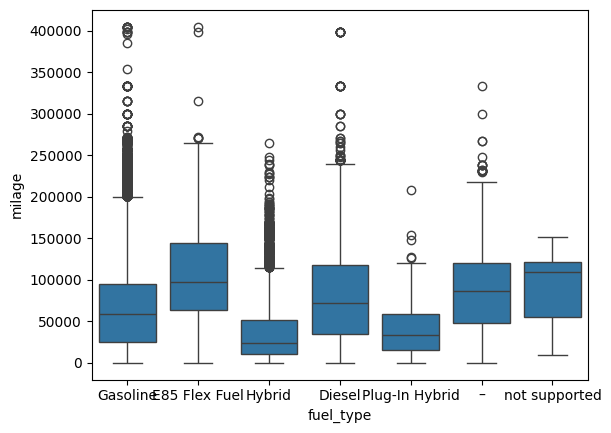

In [1256]:
# HOw brand is related to price
sns.boxplot(y='milage',x='fuel_type',data=df)

In [1257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


<Axes: xlabel='model_year', ylabel='Count'>

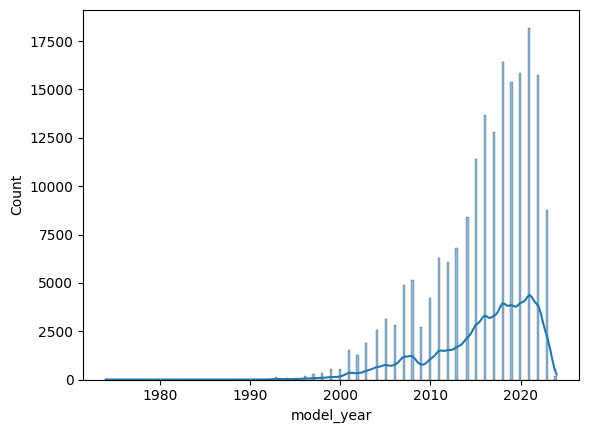

In [1258]:
sns.histplot(df['model_year'] , kde=True)

<Axes: xlabel='milage', ylabel='Count'>

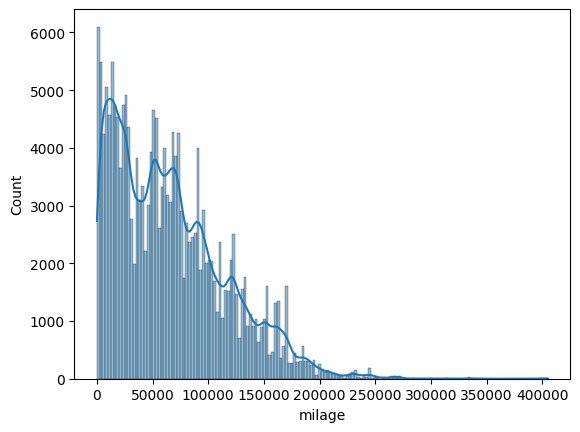

In [1259]:
sns.histplot(df['milage'] , kde=True)

<Axes: >

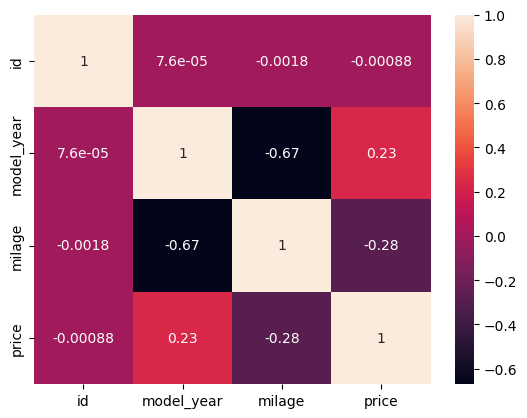

In [1260]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

<Axes: xlabel='clean_title', ylabel='count'>

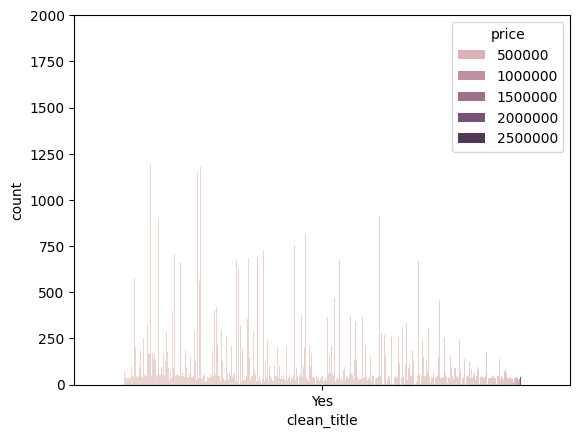

In [1261]:
sns.countplot(x = df['clean_title'], hue = df['price'])

<Axes: xlabel='accident', ylabel='count'>

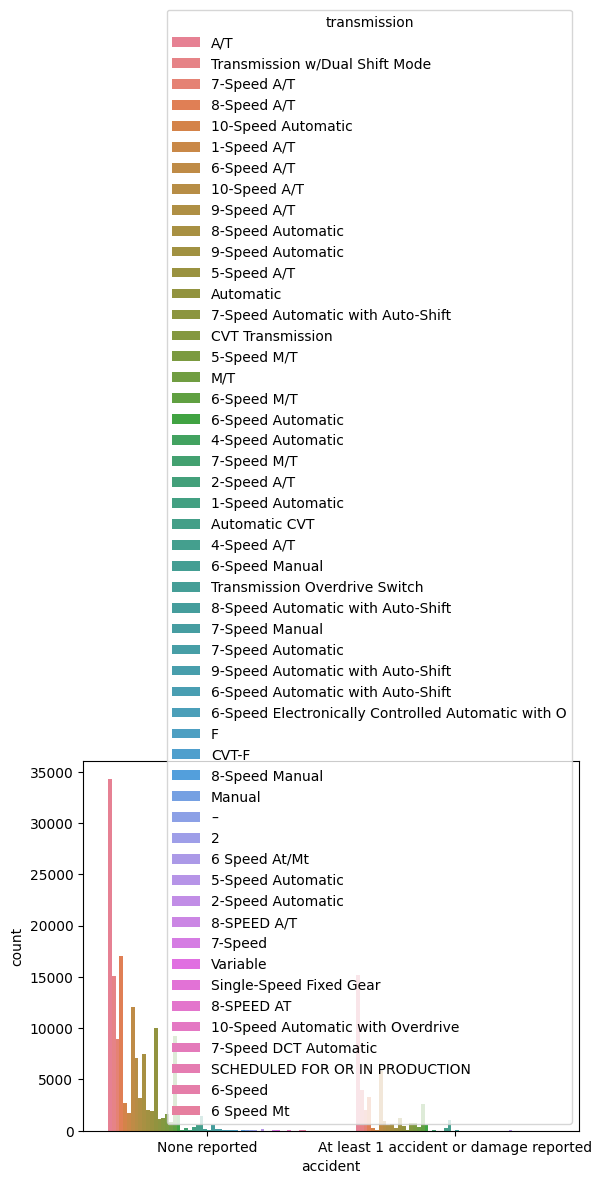

In [1262]:
sns.countplot(x = df['accident'], hue = df['transmission'])

In [1263]:
# NOw checking which data is left skewed and which data is left skewed

In [1264]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


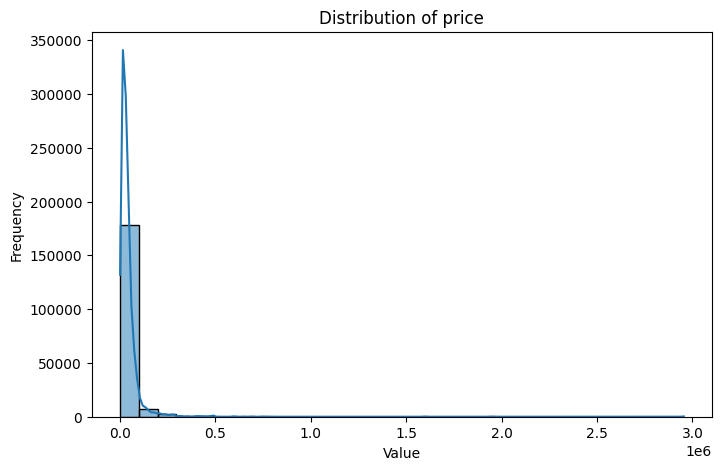

In [1265]:
data = df['price']

plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, bins=30)

plt.title('Distribution of price')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

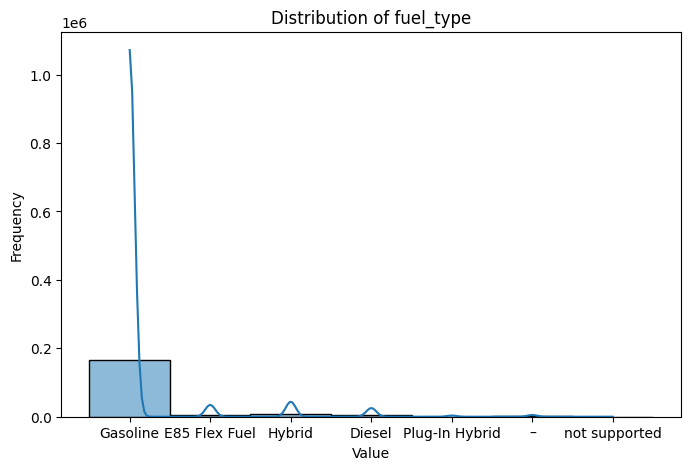

In [1266]:
data = df['fuel_type']

plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, bins=30)

plt.title('Distribution of fuel_type')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

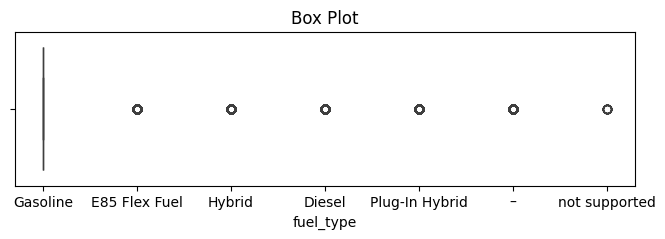

In [1267]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 2))
sns.boxplot(x=df['fuel_type'])

plt.title('Box Plot')
plt.show()

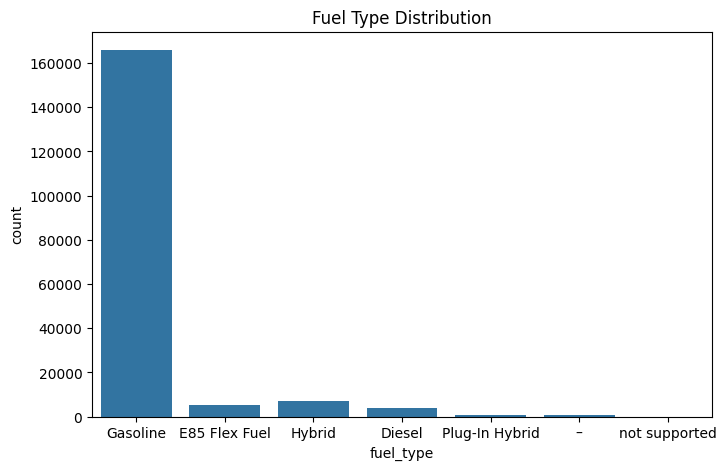

In [1268]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['fuel_type'])

plt.title('Fuel Type Distribution')
plt.show()

In [1269]:
# in this feature '-'and not supported section ,
# first i will convert both data value with NAN and then
# i will fill the null  values with mode


#df['fuel_type'] = df['fuel_type'].replace(['-', 'not supported'], np.nan)

# Fill NaN values with the mode
#df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

In [1270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


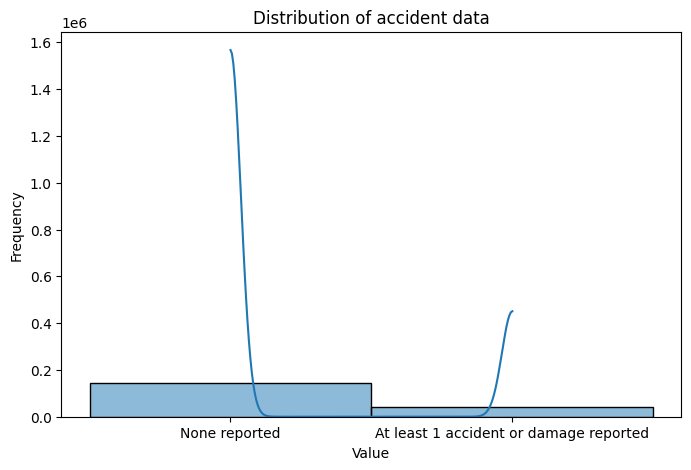

In [1271]:
# Now checking for Accidents
data = df['accident']

plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, bins=30)

plt.title('Distribution of accident data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

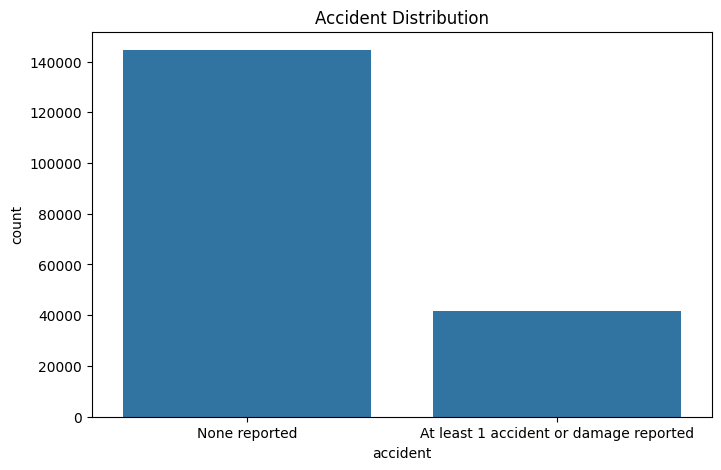

In [1272]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['accident'])

plt.title('Accident Distribution')
plt.show()

In [1273]:
df['accident'].value_counts()

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567


In [1274]:
# there are 2400 missing accidents case , and that will affect the price so i will create a new column for thos
#df['accident_missing'] = df['accident'].isna().astype(int)
#df['accident'] = df['accident'].fillna('Unknown')

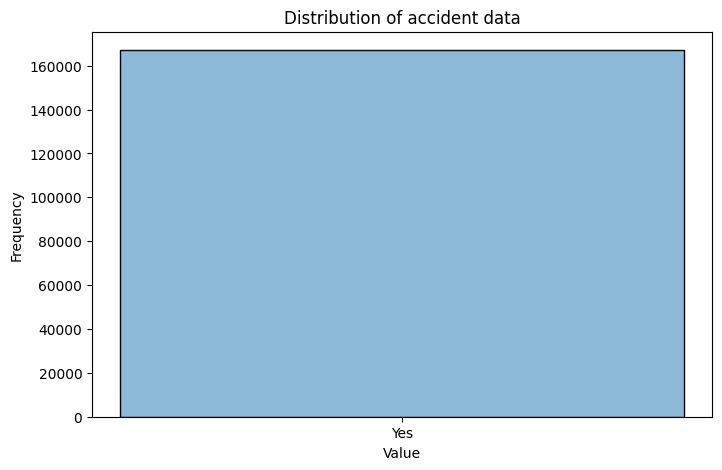

In [1275]:
## Now checking for clean_title
data = df['clean_title']

plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, bins=30)

plt.title('Distribution of accident data')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

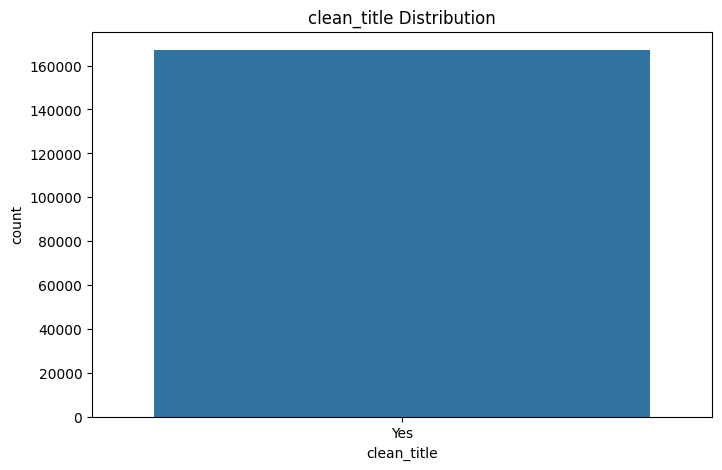

In [1276]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['clean_title'])

plt.title('clean_title Distribution')
plt.show()

In [1277]:
df['clean_title'].value_counts()

,count
clean_title,
Yes,167114


In [1278]:
df['clean_title'].isnull().sum()

np.int64(21419)

In [1279]:
df['clean_title'].value_counts(dropna=False, normalize=True) * 100

,proportion
clean_title,
Yes,88.639124
NaN,11.360876


In [1280]:
# i will fill it with mode
#df['clean_title'] = df['clean_title'].fillna(df['clean_title'].mode()[0])

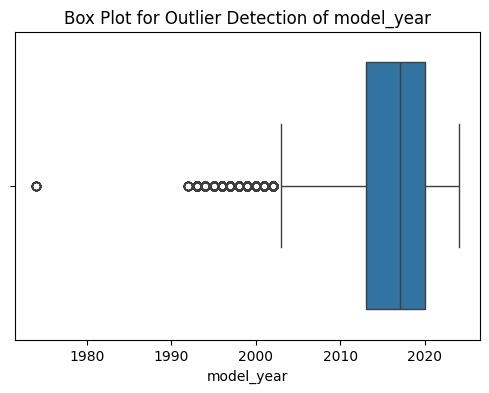

In [1281]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['model_year'])
plt.title('Box Plot for Outlier Detection of model_year')
plt.show()

In [1282]:
# Here i found an outlier lets check it

In [1283]:
print(df['model_year'].min())
print(df['model_year'].max())

1974
2024


In [1284]:
# 1974 is the outlier , i will remove it

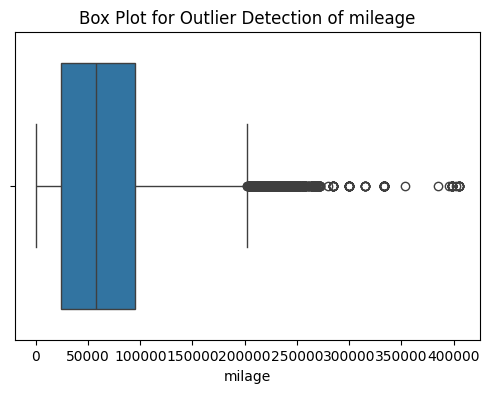

In [1285]:
# Now checking outlier for milage
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['milage'])
plt.title('Box Plot for Outlier Detection of mileage')
plt.show()

In [1286]:
# Here i got outliers and i will remove it from log

# Data Cleaning

In [1287]:
df.duplicated().sum()

np.int64(0)

In [1288]:
# Means there is no duplicate values

In [1289]:
# So now fill the null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [1290]:
# Fuel_type
# first removing the '-' and 'not supported' values
df['fuel_type'] = df['fuel_type'].replace(['–' , 'not supported'], np.nan)

In [1291]:
# NOw removing filling the null values with mode
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

In [1292]:
df['fuel_type'].unique()

array(['Gasoline', 'E85 Flex Fuel', 'Hybrid', 'Diesel', 'Plug-In Hybrid'],
      dtype=object)

In [1293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     188533 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [1294]:
## Now for Accident
# since its values can affect the price , so i will not directly remove that
df['accident'].value_counts()

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567


In [1295]:
# HEre i will create a new column name as unknown_accident for the remianing accidents
df['accident_missing'] = df['accident'].isna().astype(int)
df['accident'] = df['accident'].fillna('Unknown')

In [1296]:
print(df['accident'].value_counts(dropna=False))

accident
None reported                             144514
At least 1 accident or damage reported     41567
Unknown                                     2452
Name: count, dtype: int64


In [1297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                188533 non-null  int64 
 1   brand             188533 non-null  object
 2   model             188533 non-null  object
 3   model_year        188533 non-null  int64 
 4   milage            188533 non-null  int64 
 5   fuel_type         188533 non-null  object
 6   engine            188533 non-null  object
 7   transmission      188533 non-null  object
 8   ext_col           188533 non-null  object
 9   int_col           188533 non-null  object
 10  accident          188533 non-null  object
 11  clean_title       167114 non-null  object
 12  price             188533 non-null  int64 
 13  accident_missing  188533 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 20.1+ MB


In [1298]:
# NOw fill the null values of clean_title
# it would not much affect the price , so i will directly fill the values with mode

df['clean_title'] = df['clean_title'].fillna(df['clean_title'].mode()[0])

In [1299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                188533 non-null  int64 
 1   brand             188533 non-null  object
 2   model             188533 non-null  object
 3   model_year        188533 non-null  int64 
 4   milage            188533 non-null  int64 
 5   fuel_type         188533 non-null  object
 6   engine            188533 non-null  object
 7   transmission      188533 non-null  object
 8   ext_col           188533 non-null  object
 9   int_col           188533 non-null  object
 10  accident          188533 non-null  object
 11  clean_title       188533 non-null  object
 12  price             188533 non-null  int64 
 13  accident_missing  188533 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 20.1+ MB


In [1300]:
# Removing outlier of model_year
df = df[df['model_year'] != 1974]

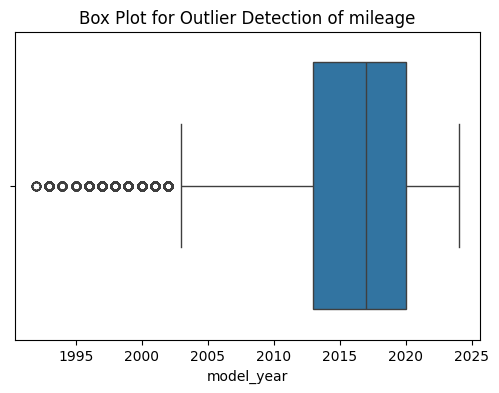

In [1301]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['model_year'])
plt.title('Box Plot for Outlier Detection of mileage')
plt.show()

In [1302]:
# REmoving outlier of milage from log

In [1303]:
outlier = df['milage'].quantile(0.99)
print(outlier)

201509.0


In [1304]:
df['milage'] = np.log1p(df['milage'])

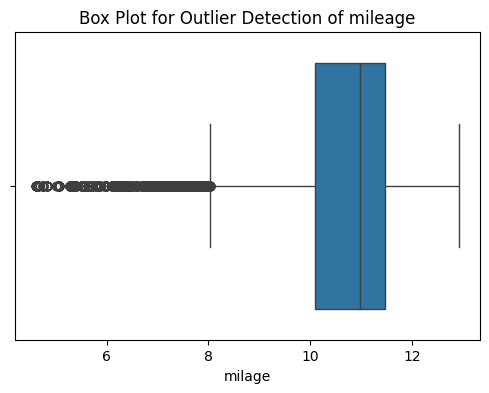

In [1305]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['milage'])
plt.title('Box Plot for Outlier Detection of mileage')
plt.show()

In [1306]:
# Removing Null values from transmission
bad_values = ['–','2','F','SCHEDULED FOR OR IN PRODUCTION']

df['transmission'] = df['transmission'].replace(bad_values, np.nan)

In [1307]:
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

In [1308]:
df['transmission'].value_counts()

,count
transmission,
A/T,50145
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11997
7-Speed A/T,11124
Automatic,10690
8-Speed Automatic,8431
10-Speed A/T,8044


In [1309]:
# Dropping the clean_title feature beacause it has maxm data of yes , and it will not help to much to predict price
df['clean_title'].value_counts()

,count
clean_title,
Yes,188521


In [1310]:
df.drop('clean_title' , axis=1 , inplace=True)

In [1311]:
# Also dropping the ID column
df.drop('id' , axis=1 , inplace=True)

# Feature Engineering

In [1312]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,accident_missing
0,MINI,Cooper S Base,2007,12.269052,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,4200,0
1,Lincoln,LS V8,2002,11.872354,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,4999,0
2,Chevrolet,Silverado 2500 LT,2002,11.825778,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,13900,0
3,Genesis,G90 5.0 Ultimate,2017,9.878221,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,45000,0
4,Mercedes-Benz,Metris Base,2021,8.907748,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,97500,0


In [1313]:
# changing the model_year to car_age


In [1314]:
from datetime import datetime

df['car_year'] = datetime.now().year - df['model_year']
df.drop('model_year', axis=1, inplace=True)

In [1315]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,accident_missing,car_year
0,MINI,Cooper S Base,12.269052,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,4200,0,19
1,Lincoln,LS V8,11.872354,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,4999,0,24
2,Chevrolet,Silverado 2500 LT,11.825778,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,13900,0,24
3,Genesis,G90 5.0 Ultimate,9.878221,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,45000,0,9
4,Mercedes-Benz,Metris Base,8.907748,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,97500,0,5


In [1316]:
# making dummies for accident
df = pd.get_dummies(df, columns=['accident'], drop_first=True)

In [1317]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,price,accident_missing,car_year,accident_None reported,accident_Unknown
0,MINI,Cooper S Base,12.269052,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,4200,0,19,True,False
1,Lincoln,LS V8,11.872354,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,4999,0,24,False,False
2,Chevrolet,Silverado 2500 LT,11.825778,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,13900,0,24,True,False
3,Genesis,G90 5.0 Ultimate,9.878221,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,45000,0,9,True,False
4,Mercedes-Benz,Metris Base,8.907748,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,97500,0,5,True,False


In [1318]:
df['accident_None reported'] = df['accident_None reported'].astype(int)
df['accident_Unknown'] = df['accident_Unknown'].astype(int)

In [1319]:
print(df['milage'].dtype)

float64


In [1320]:
# Target Encoding for features , whom i cant make dummies

In [1321]:
df.columns

Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'price', 'accident_missing', 'car_year',
       'accident_None reported', 'accident_Unknown'],
      dtype='object')

In [1322]:
pip install category_encoders

In [1323]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,price,accident_missing,car_year,accident_None reported,accident_Unknown
0,MINI,Cooper S Base,12.269052,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,4200,0,19,1,0
1,Lincoln,LS V8,11.872354,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,4999,0,24,0,0
2,Chevrolet,Silverado 2500 LT,11.825778,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,13900,0,24,1,0
3,Genesis,G90 5.0 Ultimate,9.878221,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,45000,0,9,1,0
4,Mercedes-Benz,Metris Base,8.907748,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,97500,0,5,1,0


In [1324]:
from category_encoders import TargetEncoder

In [1325]:
cols_to_encode = [
    'brand',
    'model',
    'fuel_type',
    'engine',
    'transmission',
    'ext_col',
    'int_col'
]

for col in cols_to_encode:
    df[col] = df[col].map(df.groupby(col)['price'].mean())

In [1326]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,price,accident_missing,car_year,accident_None reported,accident_Unknown
0,17162.015977,12832.716263,12.269052,43840.952249,11430.680233,31984.661063,43366.336401,28173.592689,4200,0,19,1,0
1,30721.147399,12663.379310,11.872354,43840.952249,12183.759494,31984.661063,31878.405296,29955.073902,4999,0,24,0,0
2,41836.755127,23779.677419,11.825778,26729.755457,18387.346939,31984.661063,40659.837777,28173.592689,13900,0,24,1,0
3,53556.327141,48915.842105,9.878221,43840.952249,42265.590426,50201.815580,42411.320008,45523.472709,45000,0,9,1,0
4,51244.399541,64896.257198,8.907748,43840.952249,37746.180897,47123.507371,42411.320008,29955.073902,97500,0,5,1,0


In [1327]:
#df = df.astype(int)

In [1328]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,price,accident_missing,car_year,accident_None reported,accident_Unknown
0,17162.015977,12832.716263,12.269052,43840.952249,11430.680233,31984.661063,43366.336401,28173.592689,4200,0,19,1,0
1,30721.147399,12663.379310,11.872354,43840.952249,12183.759494,31984.661063,31878.405296,29955.073902,4999,0,24,0,0
2,41836.755127,23779.677419,11.825778,26729.755457,18387.346939,31984.661063,40659.837777,28173.592689,13900,0,24,1,0
3,53556.327141,48915.842105,9.878221,43840.952249,42265.590426,50201.815580,42411.320008,45523.472709,45000,0,9,1,0
4,51244.399541,64896.257198,8.907748,43840.952249,37746.180897,47123.507371,42411.320008,29955.073902,97500,0,5,1,0


# Model Building

In [1330]:
from sklearn.model_selection import train_test_split

In [1331]:
X = df.drop('price' , axis=1)
y = df['price']

In [1334]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [1337]:
from sklearn.linear_model import LinearRegression

In [1338]:
model = LinearRegression()
model.fit(X_train , y_train)


LinearRegression()

Model Evaluation

In [1339]:
y_pred = model.predict(X_test)

In [1340]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)  / (n - p - 1))

In [1341]:
r2

0.14170194560163696

In [1342]:
adjusted_r2

0.14142868929651176